# Visualizing Trends with Line Charts

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook uses line charts to analyze and visualize trends in compensation and job satisfaction across age groups and experience levels in the developer survey data.

## Importing Libraries

I'll import the necessary libraries for data analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Loading the Dataset

I'll download and load the survey data.

In [2]:
# Download the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
# Load the data
df = pd.read_csv(url)

In [3]:
# Verify data loaded successfully
print(f"Data loaded: {len(df)} rows, {len(df.columns)} columns")

Data loaded: 65437 rows, 114 columns


In [4]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names (first 20):")
print(df.columns.tolist()[:20])

Dataset shape: (65437, 114)

Column names (first 20):
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country']


In [5]:
# Display first few rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Task 1: Trends in Compensation Over Age Groups

### Line Chart 1: Median Compensation by Age Group

I'll track how median yearly compensation changes across different age groups.

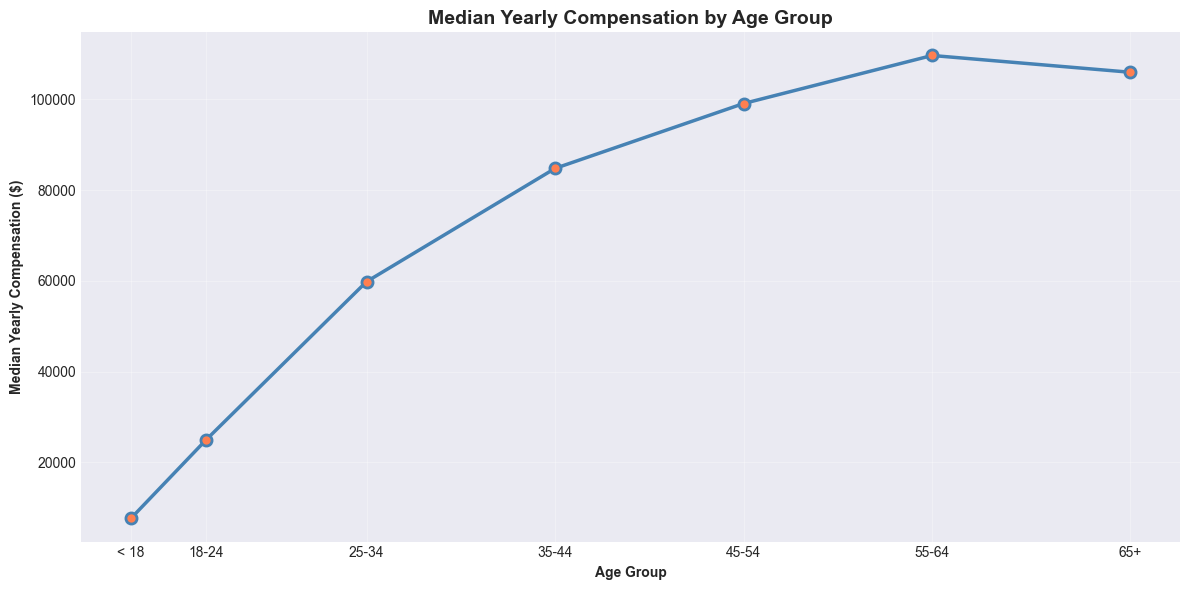


Median Compensation by Age Group:
< 18: $7,626.50
18-24: $25,000.00
25-34: $59,825.00
35-44: $84,796.00
45-54: $99,099.00
55-64: $109,691.00
65+: $106,000.00


In [6]:
# Map age to numeric values for ordering
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

# Create labels
age_labels = {
    'Under 18 years old': '< 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'
}

df['Age_Numeric'] = df['Age'].map(age_mapping)
df['Age_Label'] = df['Age'].map(age_labels)

# Prepare compensation data
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Calculate median compensation by age group
comp_by_age = df.groupby('Age_Numeric')['ConvertedCompYearly'].median().dropna()

# Get corresponding labels
age_label_map = df.groupby('Age_Numeric')['Age_Label'].first()

# Create line chart
plt.figure(figsize=(12, 6))
plt.plot(comp_by_age.index, comp_by_age.values, marker='o', linewidth=2.5, 
        markersize=8, color='steelblue', markerfacecolor='coral', 
        markeredgewidth=2, markeredgecolor='steelblue')

plt.title('Median Yearly Compensation by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontweight='bold')
plt.ylabel('Median Yearly Compensation ($)', fontweight='bold')
plt.xticks(comp_by_age.index, [age_label_map[age] for age in comp_by_age.index])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display statistics
print("\nMedian Compensation by Age Group:")
for age_num, comp in comp_by_age.items():
    print(f"{age_label_map[age_num]}: ${comp:,.2f}")

### Line Chart 2: Median Compensation for Ages 25 to 45

I'll focus on the median compensation for the prime working age group.

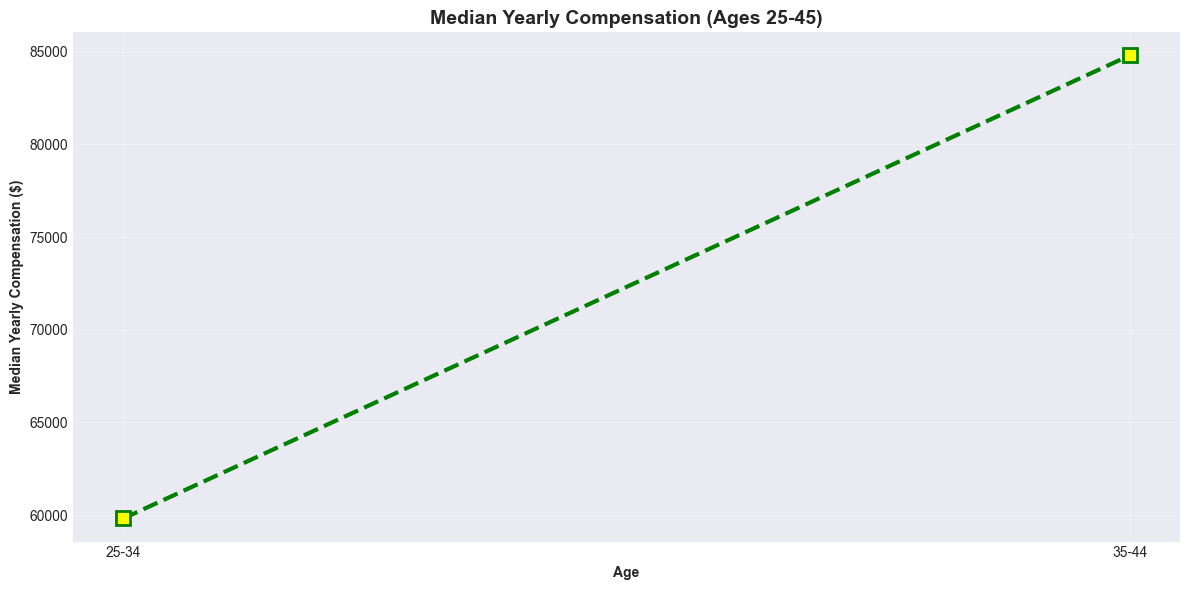


Median Compensation (Ages 25-45):
25-34: $59,825.00
35-44: $84,796.00


In [7]:
# Filter for ages 25-45 (using age groups 25-34 and 35-44)
age_25_45 = df[(df['Age_Numeric'] >= 25) & (df['Age_Numeric'] <= 45)].copy()

# Calculate median compensation
comp_25_45 = age_25_45.groupby('Age_Numeric')['ConvertedCompYearly'].median().dropna()

if len(comp_25_45) > 0:
    # Create line chart
    plt.figure(figsize=(12, 6))
    plt.plot(comp_25_45.index, comp_25_45.values, marker='s', linewidth=3, 
            markersize=10, color='green', markerfacecolor='yellow', 
            markeredgewidth=2, markeredgecolor='green', linestyle='--')
    
    plt.title('Median Yearly Compensation (Ages 25-45)', fontsize=14, fontweight='bold')
    plt.xlabel('Age', fontweight='bold')
    plt.ylabel('Median Yearly Compensation ($)', fontweight='bold')
    plt.xticks(comp_25_45.index, [age_label_map.get(age, str(age)) for age in comp_25_45.index])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nMedian Compensation (Ages 25-45):")
    for age_num, comp in comp_25_45.items():
        label = age_label_map.get(age_num, str(age_num))
        print(f"{label}: ${comp:,.2f}")
else:
    print("No data available for age range 25-45")

## Task 2: Trends in Job Satisfaction by Experience Level

### Line Chart 3: Job Satisfaction by Years of Professional Coding

I'll analyze how job satisfaction changes with coding experience.

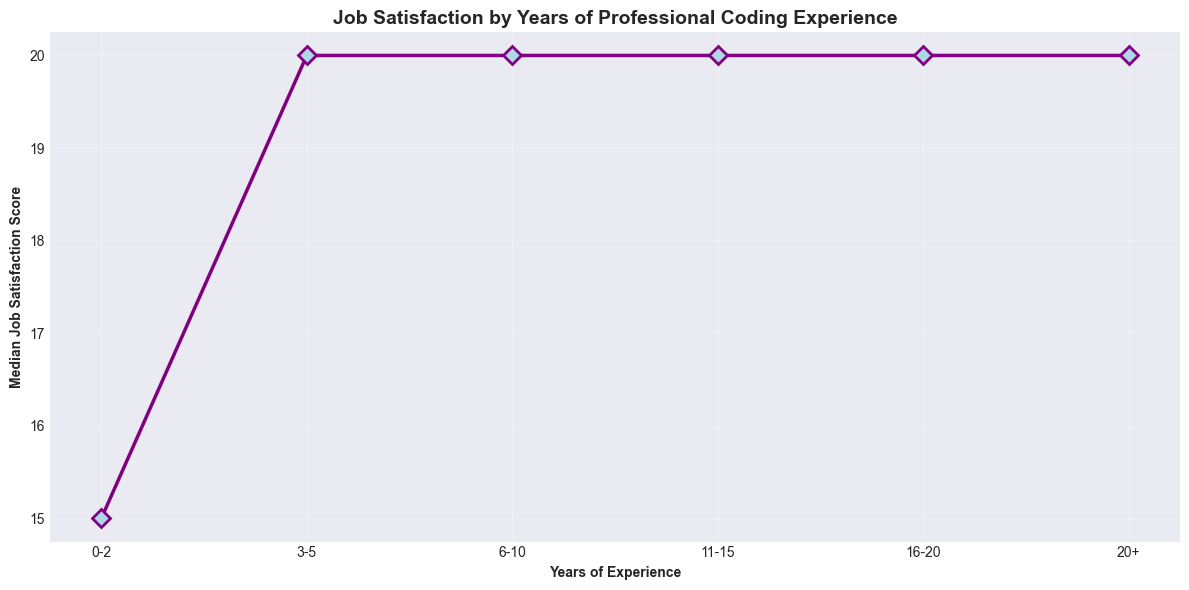


Median Job Satisfaction by Experience:
0-2 years: 15.00
3-5 years: 20.00
6-10 years: 20.00
11-15 years: 20.00
16-20 years: 20.00
20+ years: 20.00


In [8]:
# Find job satisfaction column
jobsat_col = None
for col in ['JobSatPoints_6', 'JobSat']:
    if col in df.columns:
        jobsat_col = col
        break

# Initialize these so later cells don't get NameError if columns are missing
exp_col = None
sat_col_to_use = None

if jobsat_col:
    # Use YearsCodePro as experience measure
    if 'YearsCodePro' in df.columns:
        exp_col = 'YearsCodePro'
    elif 'YearsCode' in df.columns:
        exp_col = 'YearsCode'
    
    if exp_col:
        # Prepare data
        df[exp_col] = pd.to_numeric(df[exp_col], errors='coerce')
        
        # Map job satisfaction to numeric if needed
        sat_mapping = {
            'Very satisfied': 5,
            'Slightly satisfied': 4,
            'Neither satisfied nor dissatisfied': 3,
            'Slightly dissatisfied': 2,
            'Very dissatisfied': 1
        }
        
        if df[jobsat_col].dtype == 'object':
            df['JobSat_Numeric'] = df[jobsat_col].map(sat_mapping)
            sat_col_to_use = 'JobSat_Numeric'
        else:
            sat_col_to_use = jobsat_col
        
        # Create experience bins
        exp_bins = [0, 2, 5, 10, 15, 20, 50]
        exp_labels = ['0-2', '3-5', '6-10', '11-15', '16-20', '20+']
        df['Experience_Group'] = pd.cut(df[exp_col], bins=exp_bins, labels=exp_labels)
        
        # Calculate median satisfaction by experience
        sat_by_exp = df.groupby('Experience_Group')[sat_col_to_use].median().dropna()
        
        # Create line chart
        plt.figure(figsize=(12, 6))
        plt.plot(range(len(sat_by_exp)), sat_by_exp.values, marker='D', 
                linewidth=2.5, markersize=9, color='purple', 
                markerfacecolor='lightblue', markeredgewidth=2, 
                markeredgecolor='purple')
        
        plt.title('Job Satisfaction by Years of Professional Coding Experience', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Years of Experience', fontweight='bold')
        plt.ylabel('Median Job Satisfaction Score', fontweight='bold')
        plt.xticks(range(len(sat_by_exp)), sat_by_exp.index)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\nMedian Job Satisfaction by Experience:")
        for exp_group, sat in sat_by_exp.items():
            print(f"{exp_group} years: {sat:.2f}")
    else:
        print("Experience column not found")
else:
    print("Job satisfaction column not found")


## Task 3: Compensation and Satisfaction Trends by Experience

### Line Chart 4: Median Compensation Over Experience Level

I'll track how compensation changes with increasing experience.

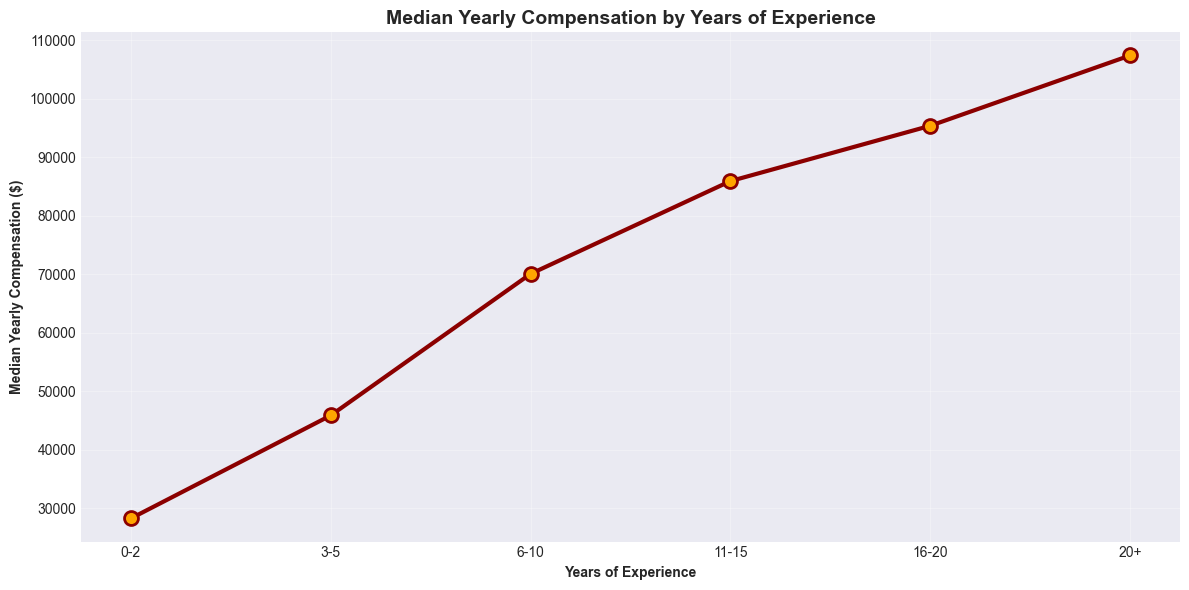


Median Compensation by Experience:
0-2 years: $28,252.00
3-5 years: $45,860.00
6-10 years: $70,063.00
11-15 years: $85,925.00
16-20 years: $95,384.00
20+ years: $107,406.00


In [9]:
# Calculate median compensation by experience group
if exp_col and 'Experience_Group' in df.columns:
    comp_by_exp = df.groupby('Experience_Group')['ConvertedCompYearly'].median().dropna()
    
    # Create line chart
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(comp_by_exp)), comp_by_exp.values, marker='o', 
            linewidth=3, markersize=10, color='darkred', 
            markerfacecolor='orange', markeredgewidth=2, 
            markeredgecolor='darkred')
    
    plt.title('Median Yearly Compensation by Years of Experience', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Years of Experience', fontweight='bold')
    plt.ylabel('Median Yearly Compensation ($)', fontweight='bold')
    plt.xticks(range(len(comp_by_exp)), comp_by_exp.index)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nMedian Compensation by Experience:")
    for exp_group, comp in comp_by_exp.items():
        print(f"{exp_group} years: ${comp:,.2f}")
else:
    print("Experience data not available")

### Line Chart 5: Job Satisfaction Across Experience Levels

I'll create a detailed line chart showing satisfaction trends throughout a developer's career.

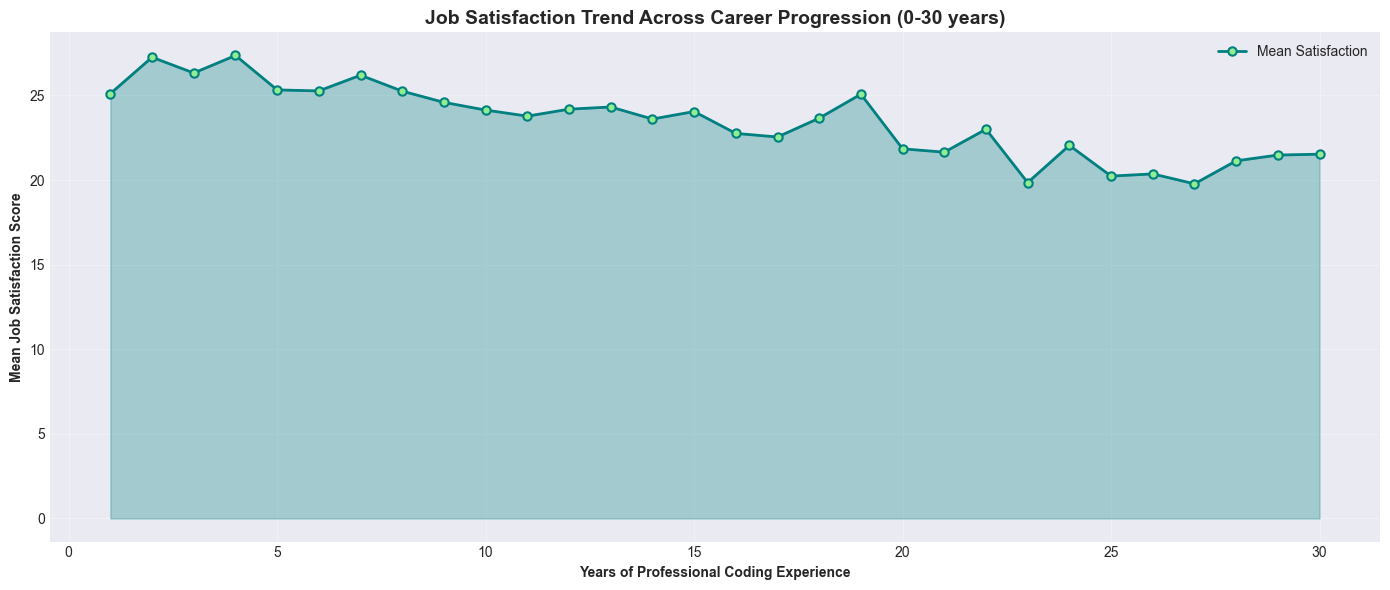


Job Satisfaction Statistics:
Early Career (0-5 years): 26.27
Mid Career (6-15 years): 24.54
Late Career (16-30 years): 21.79


In [10]:
# Create more granular experience groups
if exp_col:
    # Group by actual years (0-30)
    exp_satisfaction = df[df[exp_col] <= 30].groupby(exp_col)[sat_col_to_use].mean().dropna()
    
    if len(exp_satisfaction) > 0:
        # Create line chart with area fill
        fig, ax = plt.subplots(figsize=(14, 6))
        
        ax.plot(exp_satisfaction.index, exp_satisfaction.values, 
               marker='o', linewidth=2, markersize=6, color='teal', 
               markerfacecolor='lightgreen', markeredgewidth=1.5, 
               markeredgecolor='teal', label='Mean Satisfaction')
        
        # Fill area under the curve
        ax.fill_between(exp_satisfaction.index, exp_satisfaction.values, 
                       alpha=0.3, color='teal')
        
        ax.set_title('Job Satisfaction Trend Across Career Progression (0-30 years)', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Years of Professional Coding Experience', fontweight='bold')
        ax.set_ylabel('Mean Job Satisfaction Score', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Show key statistics
        print("\nJob Satisfaction Statistics:")
        print(f"Early Career (0-5 years): {exp_satisfaction[exp_satisfaction.index <= 5].mean():.2f}")
        print(f"Mid Career (6-15 years): {exp_satisfaction[(exp_satisfaction.index > 5) & (exp_satisfaction.index <= 15)].mean():.2f}")
        print(f"Late Career (16-30 years): {exp_satisfaction[exp_satisfaction.index > 15].mean():.2f}")
    else:
        print("Not enough data for detailed experience analysis")
else:
    print("Experience column not available")

## Bonus: Combined Trend Analysis

### Dual-Axis Line Chart: Compensation and Satisfaction Over Experience

I'll create a comprehensive view showing both metrics together.

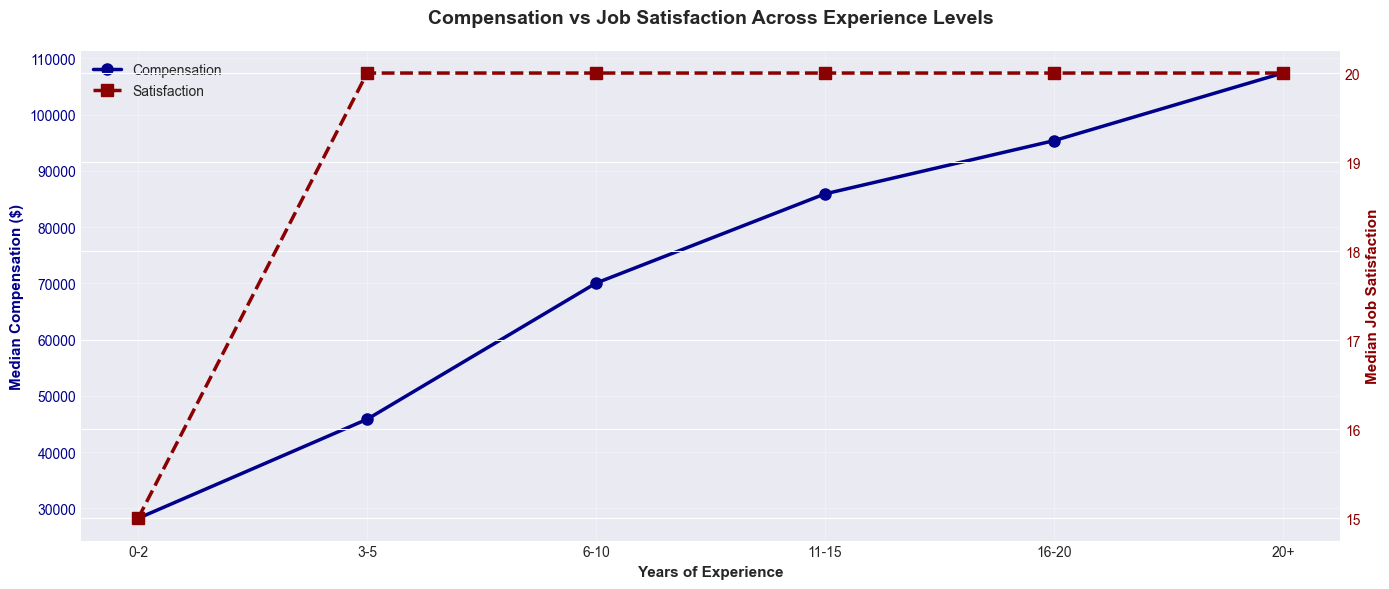


Correlation Analysis:
Correlation between Compensation and Satisfaction: 0.709


In [11]:
# Create dual-axis plot
if exp_col and 'Experience_Group' in df.columns:
    # Calculate both metrics
    comp_exp = df.groupby('Experience_Group')['ConvertedCompYearly'].median().dropna()
    sat_exp = df.groupby('Experience_Group')[sat_col_to_use].median().dropna()
    
    # Align the data
    common_groups = comp_exp.index.intersection(sat_exp.index)
    comp_exp = comp_exp[common_groups]
    sat_exp = sat_exp[common_groups]
    
    # Create figure with dual axes
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Plot compensation
    color1 = 'darkblue'
    ax1.set_xlabel('Years of Experience', fontweight='bold', fontsize=11)
    ax1.set_ylabel('Median Compensation ($)', color=color1, fontweight='bold', fontsize=11)
    line1 = ax1.plot(range(len(comp_exp)), comp_exp.values, marker='o', 
                    linewidth=2.5, markersize=8, color=color1, 
                    label='Compensation')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)
    
    # Create second y-axis
    ax2 = ax1.twinx()
    
    # Plot satisfaction
    color2 = 'darkred'
    ax2.set_ylabel('Median Job Satisfaction', color=color2, fontweight='bold', fontsize=11)
    line2 = ax2.plot(range(len(sat_exp)), sat_exp.values, marker='s', 
                    linewidth=2.5, markersize=8, color=color2, 
                    linestyle='--', label='Satisfaction')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Title and labels
    plt.title('Compensation vs Job Satisfaction Across Experience Levels', 
             fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(range(len(comp_exp)))
    ax1.set_xticklabels(comp_exp.index)
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    print("\nCorrelation Analysis:")
    correlation = comp_exp.corr(sat_exp)
    print(f"Correlation between Compensation and Satisfaction: {correlation:.3f}")
else:
    print("Not enough data for combined analysis")

## Summary

In this notebook, I created 6 line charts to analyze trends in compensation and job satisfaction:

**Task 1: Compensation Trends by Age**
- Median yearly compensation across all age groups
- Focused analysis on ages 25-45 (prime working years)

**Task 2: Job Satisfaction by Experience**
- Job satisfaction trends by years of professional coding experience

**Task 3: Compensation & Satisfaction by Experience**
- Median compensation growth over experience levels
- Detailed satisfaction trends across career progression (0-30 years)

**Bonus: Combined Analysis**
- Dual-axis chart showing compensation and satisfaction together

### Key Insights from Line Charts:

Line charts are excellent for:
- **Tracking trends** - Show how values change over continuous variables
- **Identifying patterns** - Spot increases, decreases, or plateaus
- **Comparing trajectories** - Multiple lines show different trends
- **Time series analysis** - Perfect for sequential data

### Visualization Techniques Used:

- **Markers** - Different shapes (circles, squares, diamonds) for emphasis
- **Line styles** - Solid, dashed, and customized widths
- **Color coding** - Distinct colors for different metrics
- **Fill areas** - Shaded regions under curves for visual impact
- **Dual axes** - Compare metrics with different scales
- **Custom markers** - Edge colors and face colors for better visibility

### Findings:

These line charts revealed:
- Compensation generally increases with age and experience
- Job satisfaction patterns across career stages
- Relationship between compensation growth and satisfaction
- Critical career transition points in the developer community

Line charts are invaluable for understanding how metrics evolve and for identifying trends that inform career decisions and workforce planning.